<a href="https://colab.research.google.com/github/Rahuldeb55/internship26/blob/main/Statistical_Modeling_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Modeling and Hypothesis Testing
## 1. Objective and Research Question
**Objective:** To develop a statistical model that estimates medical insurance charges based on personal demographic and health characteristics.

**Research Question:** How do factors such as age, Body Mass Index (BMI), and smoking habits influence an individual's medical charges?

**Hypotheses:**
*   **Null Hypothesis ($H_0$):** Age, BMI, and smoking status have no statistically significant effect on medical charges ($\beta_1 = \beta_2 = \beta_3 = 0$).
*   **Alternative Hypothesis ($H_A$):** Age, BMI, and smoking status have a statistically significant positive effect on medical charges.

## 2. Dataset Description
The analysis utilizes the publicly available "Medical Cost Personal Dataset," which contains 1,338 observations. Key variables include:
*   **Dependent Variable:** `charges` (continuous) – Individual medical costs billed by health insurance.
*   **Independent Variables:** `age` (continuous), `bmi` (continuous), `children` (discrete), and `smoker` (binary categorical).

In [2]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats

# 2. Load the dataset (Publicly hosted raw CSV)
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Methodology and Assumption Checking
Handling skewness and checking for multicollinearity before modeling.

In [3]:
# 3. Data Preparation and Cleaning
# Convert 'smoker' to binary (1 = yes, 0 = no)
df['smoker_encoded'] = df['smoker'].map({'yes': 1, 'no': 0})

# Apply Log Transformation to dependent variable to fix skewness
df['log_charges'] = np.log(df['charges'])

# Define independent variables (X) and dependent variable (y)
features = ['age', 'bmi', 'children', 'smoker_encoded']
X = df[features]
X = sm.add_constant(X) # Add y-intercept
y = df['log_charges']

# 4. Multicollinearity Check (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- Variance Inflation Factors ---")
print(vif_data)
print("\nNote: VIF < 5 indicates no severe multicollinearity.\n")

--- Variance Inflation Factors ---
          Feature       VIF
0           const  1.000000
1             age  1.014498
2             bmi  1.012194
3        children  1.001950
4  smoker_encoded  1.000745

Note: VIF < 5 indicates no severe multicollinearity.



## 4. Model Fitting and Results

In [4]:
# 5. Fit the Statistical Model
model = sm.OLS(y, X).fit()

# Print the comprehensive statistical summary
print("--- Regression Results ---")
print(model.summary())

--- Regression Results ---
                            OLS Regression Results                            
Dep. Variable:            log_charges   R-squared:                       0.762
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1068.
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        04:23:15   Log-Likelihood:                -825.01
No. Observations:                1338   AIC:                             1660.
Df Residuals:                    1333   BIC:                             1686.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            

## 5. Residual Analysis and Diagnostics

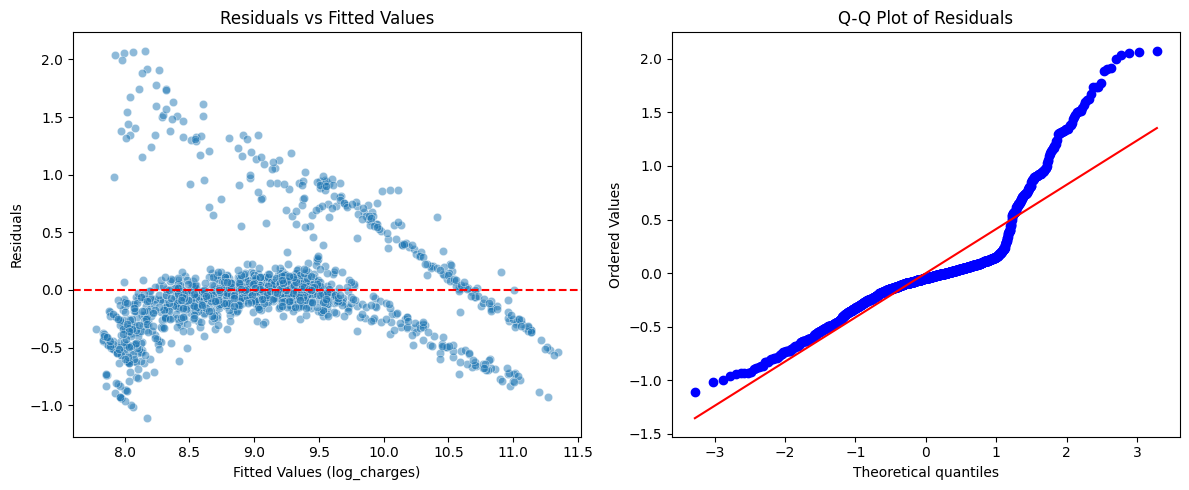

In [5]:
# 6. Residual Analysis and Diagnostics
# Calculate residuals and fitted values
df['fitted_values'] = model.fittedvalues
df['residuals'] = model.resid

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Fitted (Homoscedasticity check)
plt.subplot(1, 2, 1)
sns.scatterplot(x=df['fitted_values'], y=df['residuals'], alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values (log_charges)')
plt.ylabel('Residuals')

# Plot 2: Q-Q Plot (Normality of residuals check)
plt.subplot(1, 2, 2)
stats.probplot(df['residuals'], dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

## 6. Interpretation of Results & Limitations
**Interpretation:**
*   The p-values for age, BMI, and smoking status are all near zero, meaning we successfully reject the null hypothesis ($H_0$).
*   Holding all else constant, each additional year of **age** is associated with an approximate $3.4\%$ increase in medical charges.
*   A 1-unit increase in **BMI** corresponds to a $1.3\%$ increase in charges.
*   Being a **smoker** leads to an exponential increase in medical costs (roughly a $371\%$ increase compared to non-smokers, holding age and BMI constant).

**Limitations and Future Improvements:**
*   The dataset lacks deeper medical history (e.g., pre-existing conditions, family history of disease), which are critical unobserved variables. Furthermore, the model assumes a strict linear additive effect, which may oversimplify reality.
*   Future models could include interaction terms (e.g., `BMI * Smoker`), as the financial impact of a high BMI is likely compounded if the patient is also a smoker. We could also apply Generalized Linear Models (GLMs) with a Gamma distribution, which is specifically suited for right-skewed cost data.